# Exploratory Data Analysis (EDA)

This notebook explores the cleaned video game sales dataset to understand key patterns and relationships in the data. The goal of the exploratory analysis is to identify trends in game sales, examine differences across genres and platforms, and investigate how factors such as critic scores and release timing relate to commercial performance.
The analysis focuses on:

 * Distribution of global and regional video game sales
 * Sales performance across genres, platforms, and publishers
 * Regional differences in gaming preferences
 * The relationship between critic scores and commercial success
 * Temporal trends in game releases and sales

Insights from this stage will guide later steps in the project, including statistical analysis and machine learning modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

# Load the dataset
df = pd.read_csv('C:/Users/ADMIN/Downloads/gamessales_project/dataset/cleaned/cleaned.csv')
df.head(10)

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date,release_year,release_month,sales_sum
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0,9.0,20.33
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0,11.0,19.39
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0,10.0,16.15
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,6.8,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0,9.0,15.87
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0,11.0,15.08
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,2011.0,11.0,14.82
6,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,2010.0,11.0,14.74
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018.0,10.0,13.94
8,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2012.0,11.0,13.86
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2012.0,11.0,13.80


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18922 entries, 0 to 18921
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             18922 non-null  object 
 1   console           18922 non-null  object 
 2   genre             18922 non-null  object 
 3   publisher         18922 non-null  object 
 4   developer         18922 non-null  object 
 5   critic_score      18922 non-null  float64
 6   total_sales(mil)  18922 non-null  float64
 7   na_sales(mil)     18922 non-null  float64
 8   jp_sales(mil)     18922 non-null  float64
 9   pal_sales(mil)    18922 non-null  float64
 10  other_sales(mil)  18922 non-null  float64
 11  release_date      18832 non-null  object 
 12  release_year      18922 non-null  float64
 13  release_month     18922 non-null  float64
 14  sales_sum         18922 non-null  float64
dtypes: float64(9), object(6)
memory usage: 2.2+ MB
None


In [3]:
# Top selling games
df.sort_values('total_sales(mil)', ascending=False)[
    ['title','console','genre','publisher','total_sales(mil)']
].head(10)

,title,console,genre,publisher,total_sales(mil)
0,Grand Theft Auto V,PS3,Action,Rockstar Games,20.32
1,Grand Theft Auto V,PS4,Action,Rockstar Games,19.39
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,16.15
3,Grand Theft Auto V,X360,Action,Rockstar Games,15.86
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,15.09
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,14.82
6,Call of Duty: Black Ops,X360,Shooter,Activision,14.74
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,13.94
8,Call of Duty: Black Ops II,X360,Shooter,Activision,13.86
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,13.80


In [4]:
top3 = (
    df.groupby('genre', group_keys=False)
      .apply(lambda x: x.nlargest(3, 'critic_score'))
      .sort_values(['genre', 'critic_score'], ascending=[True, False])
)

top3[['genre', 'title', 'console','critic_score']][:9]

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5936\1640574847.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'critic_score'))


,genre,title,console,critic_score
16,Action,Grand Theft Auto IV,X360,10.0
19,Action,Grand Theft Auto IV,PS3,10.0
1191,Action,Red Dead Redemption: Undead Nightmare,PS3,10.0
7,Action-Adventure,Red Dead Redemption 2,PS4,9.8
236,Action-Adventure,Assassin's Creed Odyssey,PS4,9.5
1165,Action-Adventure,Shadow of the Colossus,PS4,9.3
1927,Adventure,The Walking Dead: A Telltale Games Series,PS3,9.7
1000,Adventure,Grand Theft Auto: Chinatown Wars,DS,9.5
557,Adventure,The Legend of Zelda: Oracle of Ages,GBC,9.4


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5936\85772980.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


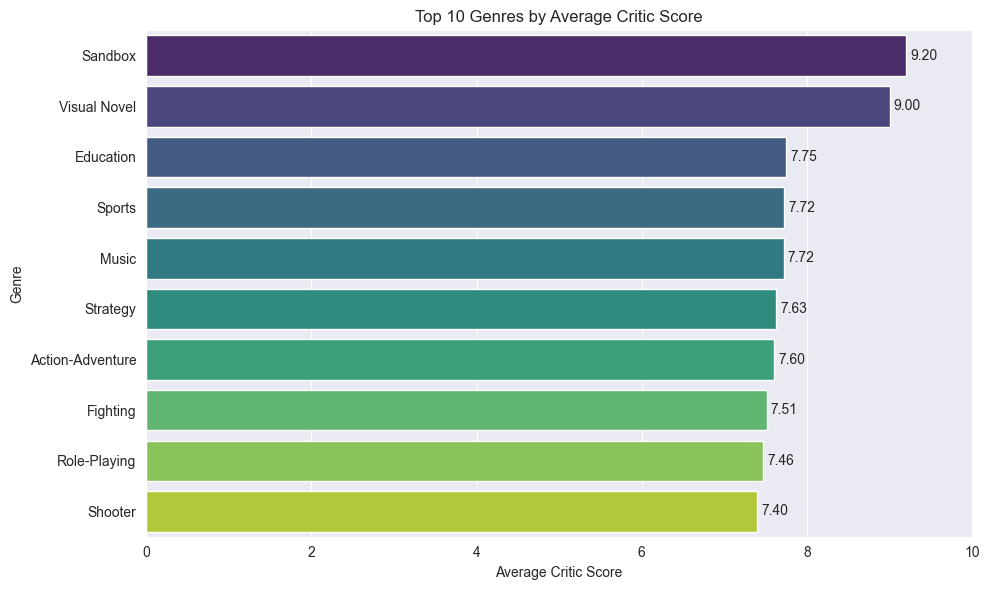

In [5]:
top10_genre = (
    df.groupby('genre')['critic_score']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top10_genre.values,
    y=top10_genre.index,
    palette='viridis'
)

plt.title('Top 10 Genres by Average Critic Score')
plt.xlabel('Average Critic Score')
plt.ylabel('Genre')

# add value labels
for i, v in enumerate(top10_genre.values):
    ax.text(v + 0.05, i, f"{v:.2f}", va='center')

plt.xlim(0, 10)
plt.tight_layout()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5936\1196799616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="mako")


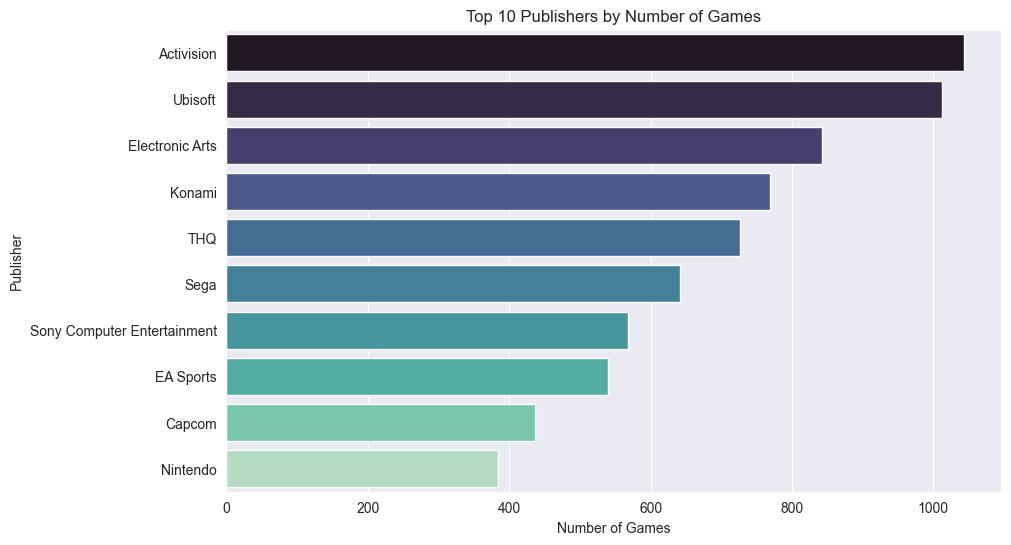

In [6]:
# Top publishers by number of games
top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="mako")

plt.title("Top 10 Publishers by Number of Games")
plt.xlabel("Number of Games")
plt.ylabel("Publisher")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5936\2557458272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


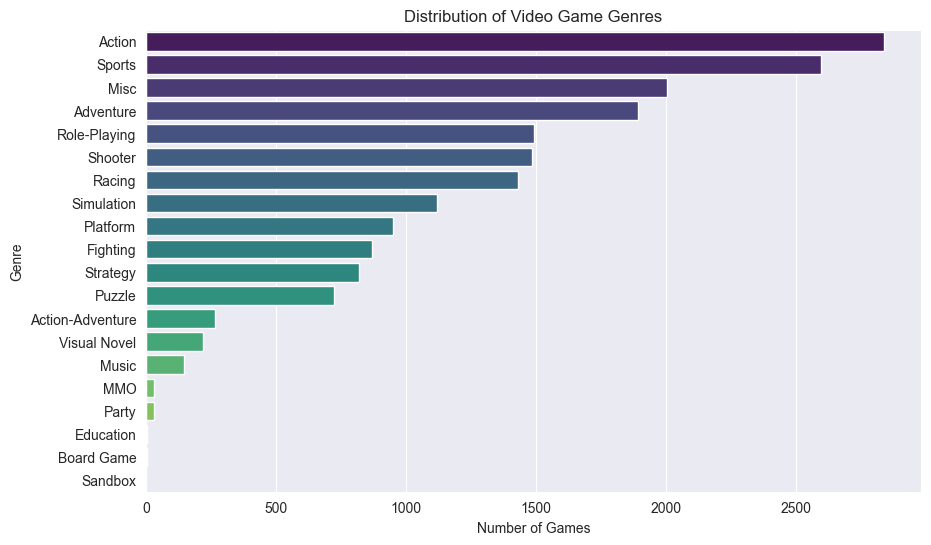

In [7]:
genre_counts = df['genre'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")

plt.title("Distribution of Video Game Genres")
plt.xlabel("Number of Games")
plt.ylabel("Genre")
plt.show()

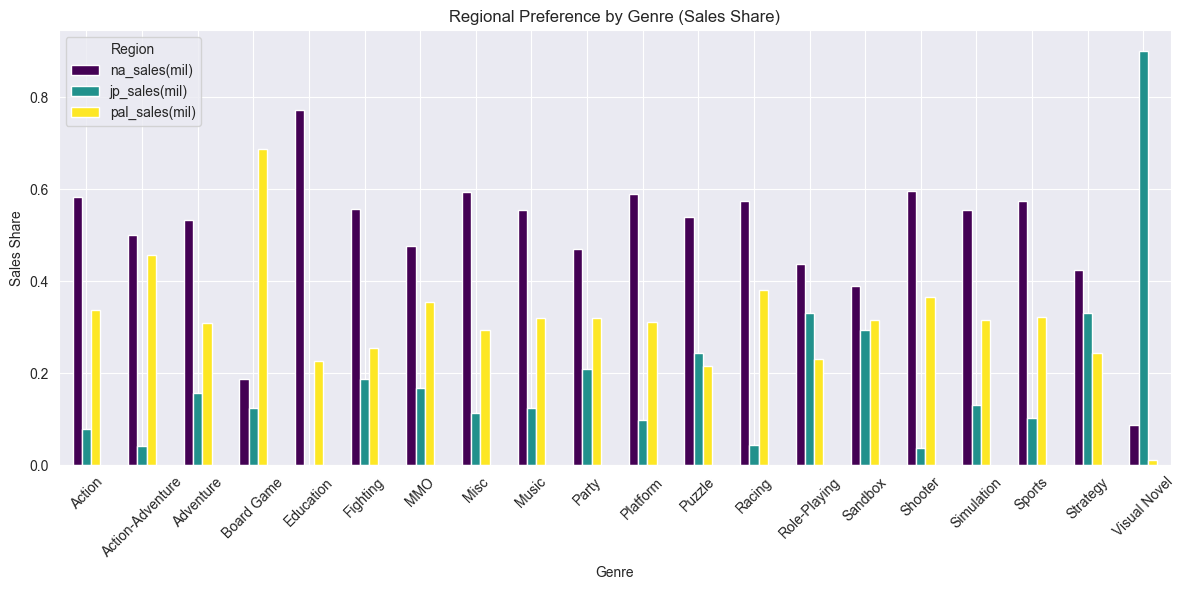

In [8]:
region_genre = df.groupby('genre')[
    ['na_sales(mil)','jp_sales(mil)','pal_sales(mil)']
].sum()

# convert to percentage
region_genre_pct = region_genre.div(region_genre.sum(axis=1), axis=0)

region_genre_pct.plot(
    kind='bar',
    figsize=(12,6),
    colormap='viridis'
)

plt.title("Regional Preference by Genre (Sales Share)")
plt.ylabel("Sales Share")
plt.xlabel("Genre")
plt.legend(title="Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

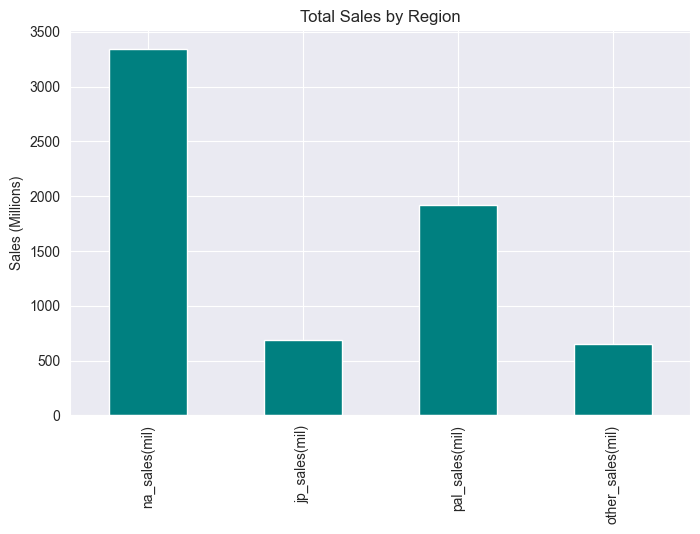

In [9]:
region_sales = df[
    ['na_sales(mil)','jp_sales(mil)','pal_sales(mil)','other_sales(mil)']
].sum()

region_sales.plot(kind='bar', figsize=(8,5), color='teal')
plt.title("Total Sales by Region")
plt.ylabel("Sales (Millions)")
plt.show()

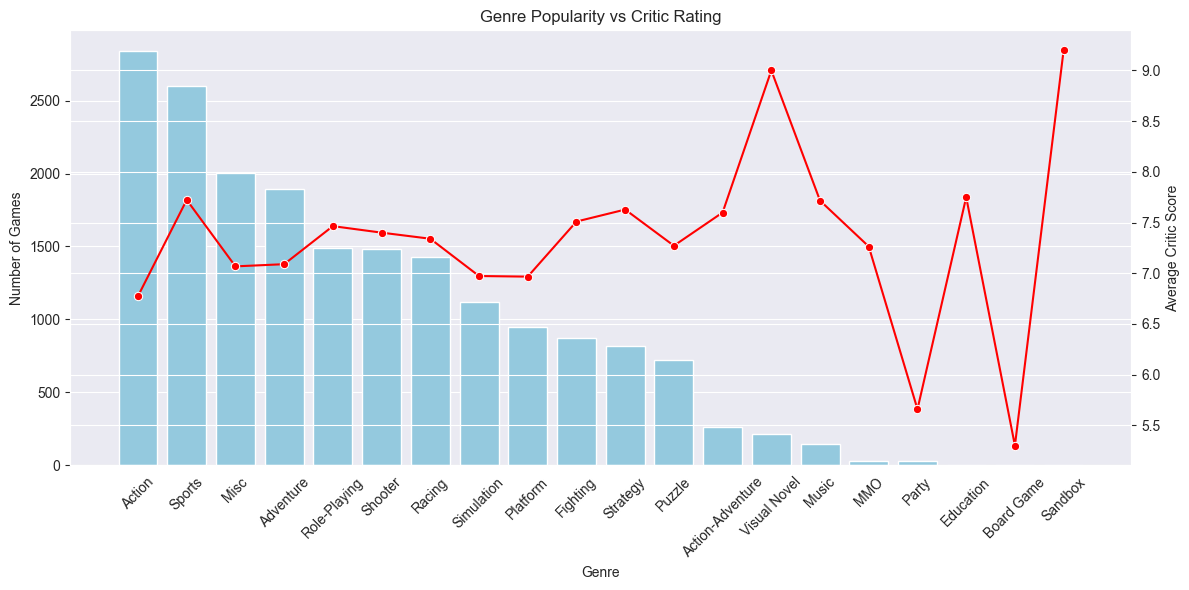

In [10]:
# Number of Games vs Average Critic Score by Genre
genre_stats = df.groupby('genre').agg(
    game_count=('title','count'),
    avg_score=('critic_score','mean')
).sort_values('game_count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12,6))

sns.barplot(
    x=genre_stats.index,
    y=genre_stats['game_count'],
    color='skyblue',
    ax=ax1
)

ax1.set_ylabel("Number of Games")
ax1.set_xlabel("Genre")
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()

sns.lineplot(
    x=genre_stats.index,
    y=genre_stats['avg_score'],
    marker="o",
    color="red",
    ax=ax2
)

ax2.set_ylabel("Average Critic Score")

plt.title("Genre Popularity vs Critic Rating")
plt.tight_layout()
plt.show()

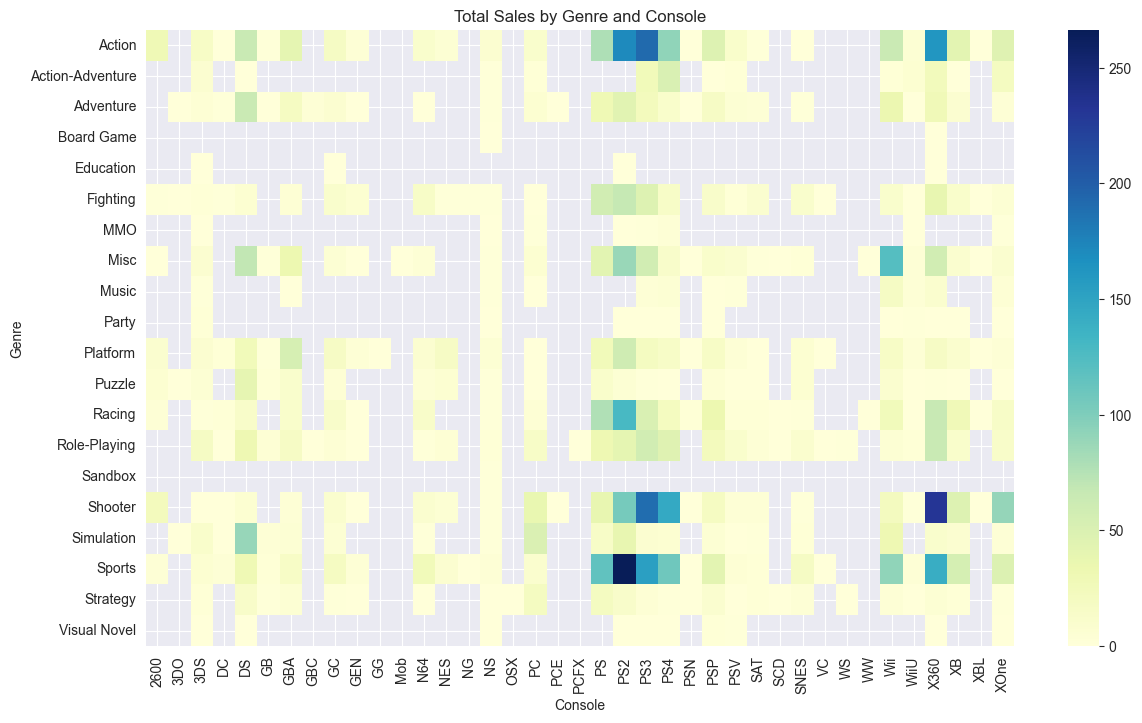

In [11]:
# Heatmap for Genre vs Console Sales with total sales as values
pivot = df.pivot_table(
    values='total_sales(mil)',
    index='genre',
    columns='console',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlGnBu')

plt.title("Total Sales by Genre and Console")
plt.xlabel("Console")
plt.ylabel("Genre")
plt.show()

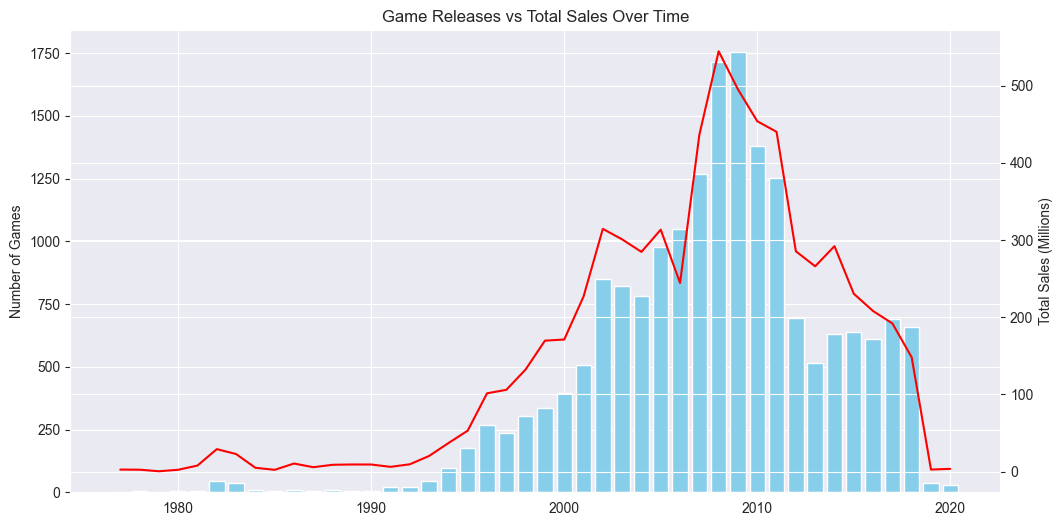

In [12]:
# number of games released + total sales
games = df.groupby('release_year')['title'].count()
sales = df.groupby('release_year')['total_sales(mil)'].sum()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(games.index, games.values, color='skyblue')
ax1.set_ylabel("Number of Games")

ax2 = ax1.twinx()
ax2.plot(sales.index, sales.values, color='red')
ax2.set_ylabel("Total Sales (Millions)")

plt.title("Game Releases vs Total Sales Over Time")
plt.xlabel("Release Year")
plt.show()

## Key Observations from Initial Exploration

Several interested insights emerge from the preliminary inspection of the dataset we got here.

First, Action, Sports, and Miscellaneous games dominate the dataset in terms of the number of releases, with Action games being the most common genre by a significant margin. In contrast, genres such as MMO, Music, Party, and Sandbox games appear relatively rarely, suggesting that these categories represent smaller segments of the market.

Looking at publisher activity, a small number of companies account for a large proportion of game releases. Activision, Ubisoft, and Electronic Arts appear among the most active publishers, highlighting the influence of major industry players in game production and distribution.

In terms of regional market size, North America clearly represents the largest video game market, followed by the PAL region (Europe and Australia). Sales in Japan are significantly smaller, while the “Other” region contributes the smallest share overall. This suggests strong geographic concentration of video game consumption in Western markets.

The regional sales distribution also reveals clear differences in gaming preferences. North America contributes the largest share of sales across most genres, particularly in action-oriented categories such as Shooter, Sports, and Platform games. The PAL region generally follows similar trends but with a more balanced distribution across genres. In contrast, Japan shows stronger relative sales in genres such as Role-Playing and Visual Novel games, highlighting distinct regional preferences in game styles.

The highest selling games are dominated by large blockbuster franchises such as Grand Theft Auto and Call of Duty, which appear multiple times among the top selling titles. This indicates that well-established franchises play a major role in commercial success.

When examining critic scores across genres, some less common genres such as Sandbox and Visual Novel show the highest average ratings. However, these genres also have relatively few releases, which may make their average scores more sensitive to individual titles. More common genres such as Action, Shooter, and Role-Playing games maintain strong but slightly lower average critic scores.

The temporal analysis shows that both the number of game releases and total sales increased steadily from the mid-1990s, reaching a peak during the late 2000s to early 2010s. This period likely corresponds to the peak of major console generations such as the PlayStation 3, Xbox 360, and Nintendo Wii. After this peak, both the number of releases and overall sales begin to decline, suggesting changes in the industry such as market saturation, shifts toward digital distribution, and the rise of alternative gaming platforms like mobile gaming.

Finally, the heatmap of genre versus console sales suggests that certain genre–platform combinations generate substantially higher sales, indicating potential specialization of game types across gaming platforms.

# Relationship Analysis: how variables relate to sales?

This section will investigate on: 

* Do higher critic scores lead to higher sales?
* Which genres generate the most revenue?
* Which consoles perform best?
* Are some publishers consistently successful?

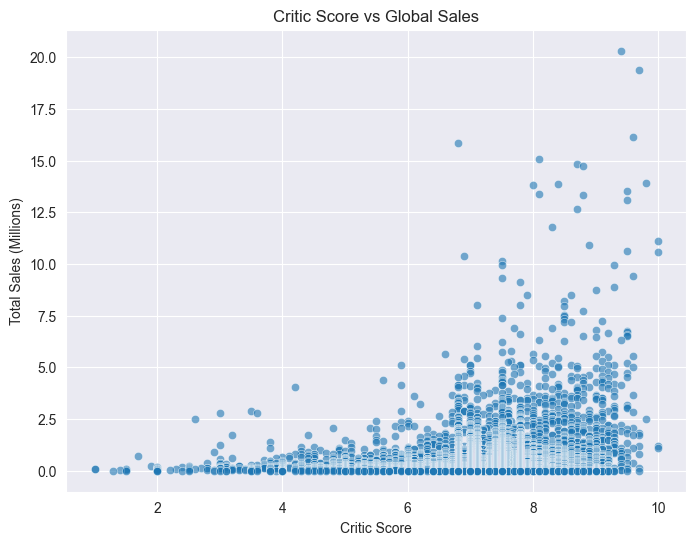

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='critic_score',
    y='total_sales(mil)',
    alpha=0.6
)

plt.title("Critic Score vs Global Sales")
plt.xlabel("Critic Score")
plt.ylabel("Total Sales (Millions)")
plt.show()

In [14]:
df[['critic_score','total_sales(mil)']].corr()

,critic_score,total_sales(mil)
critic_score,1.000000,0.177871
total_sales(mil),0.177871,1.000000


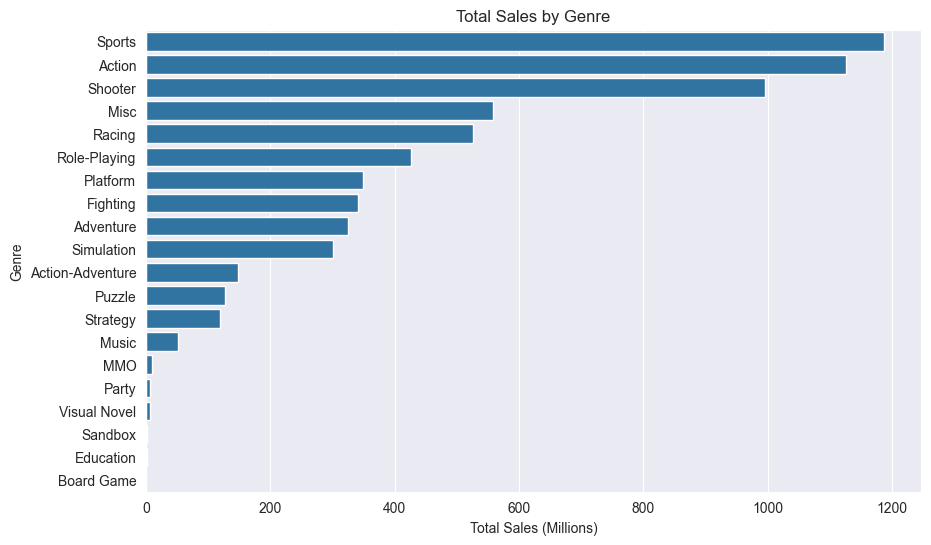

In [15]:
genre_sales = df.groupby('genre')['total_sales(mil)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_sales.values, y=genre_sales.index)

plt.title("Total Sales by Genre")
plt.xlabel("Total Sales (Millions)")
plt.ylabel("Genre")
plt.show()

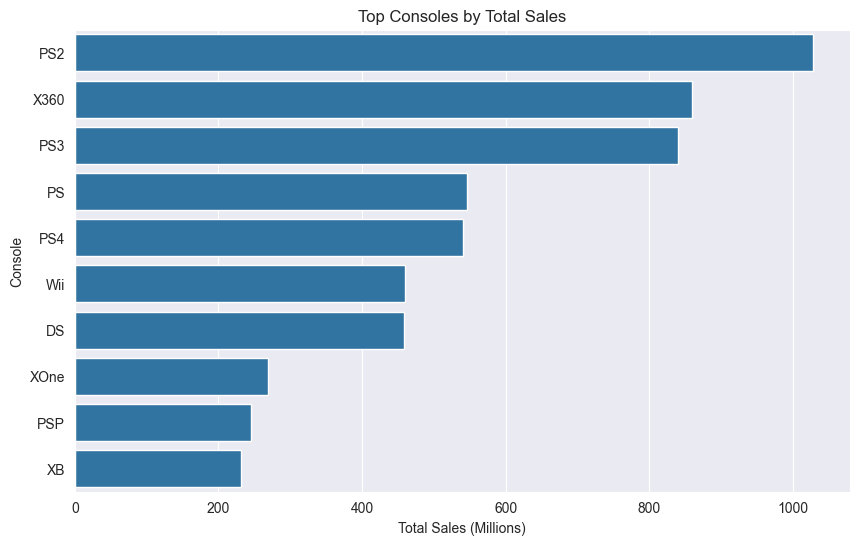

In [16]:
console_sales = df.groupby('console')['total_sales(mil)'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=console_sales.values, y=console_sales.index)

plt.title("Top Consoles by Total Sales")
plt.xlabel("Total Sales (Millions)")
plt.ylabel("Console")
plt.show()

In [17]:
publisher_perf = df.groupby('publisher').agg(
    games=('title','count'),
    avg_sales=('total_sales(mil)','mean')
)

publisher_perf = publisher_perf[publisher_perf['games'] > 50]

publisher_perf.sort_values('avg_sales', ascending=False).head(10)

,games,avg_sales
publisher,,
Rockstar Games,93,2.577097
Bethesda Softworks,113,0.983009
EA Sports,540,0.899370
LucasArts,138,0.858551
Electronic Arts,843,0.764093
Activision,1044,0.692308
Microsoft Game Studios,92,0.637391
Warner Bros. Interactive Entertainment,166,0.623554
Warner Bros. Interactive,126,0.619603


## Key Insights from Relationship Analysis

The relationship analysis highlights several important patterns in the video game market. First, while there is a positive relationship between critic scores and sales, the correlation is relatively weak (≈0.18), suggesting that high critic ratings alone are not strong predictors of commercial success. Some highly rated games achieve strong sales, but many titles with moderate scores still perform well commercially.

Examining sales across genres shows that Sports, Action, and Shooter games generate the highest total sales, indicating that fast-paced and competitive genres dominate the global market. In contrast, niche genres such as MMO, Visual Novel, and Party games contribute only a small portion of overall sales.

From a platform perspective, PlayStation 2, Xbox 360, and PlayStation 3 stand out as the consoles with the highest cumulative sales, reflecting the success of these console generations during the peak years of the gaming industry.

Finally, when examining publisher performance, Rockstar Games stands out with the highest average sales per title, significantly outperforming other major publishers. This is likely driven by blockbuster franchises such as Grand Theft Auto and Red Dead Redemption, demonstrating the strong impact that high-profile titles can have on overall publisher success.

Together, these results suggest that genre choice, platform popularity, and publisher strength play a larger role in commercial success than critic ratings alone.